In [1]:
import pandas as pd
import os.path as op
import platform
import glob
import os
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import pingouin

In [27]:
wanted_dir = "/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-07"
other_dir = "/Users/sbedi/Downloads"

V0_file =  glob.glob(other_dir + '/V0_Transfer.npy')
V1_file =  glob.glob(other_dir + '/V1_Transfer.npy')
spe_file = glob.glob(wanted_dir + '/spe.npy')

wanted_dir = "/data/sourcedata/behavior/modified_files"

file = "modified_participant07_savedValues.csv"
file = file[:-1]

data_folder = '/Volumes/SDrive/data/'

In [28]:
# Creating dataFrame with relevant indices and fitted values and RT. 
Vdiff_abs_data = []
V0data = []
V1data = []
Vdiff_data = []
Vsum_data = []
spe_data = []
# subject = []


spe = np.load(spe_file[0])
spe_data.append(spe)
V0 = np.load(V0_file[0])
V1 = np.load(V1_file[0])
V0data.append(V0)
V1data.append(V1)
# V1_data.append(V0)
Vdiff = (V1 - V0)
# print(np.shape(Vdiff))
# Vdiff = (np.abs(V0-V1))
Vdiff_abs = np.abs(Vdiff)    
Vdiff_data.append(Vdiff)
Vdiff_abs_data.append(Vdiff_abs)
Vsum = (V0+V1)
Vsum_data.append(Vsum)
# subject.append(29)
    
# Flatten the data lists
V0data = np.array(V0data).flatten()
V1data = np.array(V1data).flatten()
Vdiff_data = np.array(Vdiff_data).flatten()
Vdiff_abs_data = np.array(Vdiff_abs_data).flatten()
Vsum_data = np.array(Vsum_data).flatten()
spe_data = np.array(spe_data).flatten()

# Create the index values for runNumber, trialNumber, and subject
runNumber = np.tile(np.repeat(np.arange(1, 7), 60), 1)
trialNumber = np.tile(np.arange(1, 61), 6 * 1)

# Create the DataFrame
df = pd.DataFrame({
    'V0': V0data,
    'V1': V1data,
    'Vdiff_abs': Vdiff_abs_data,
    'Vdiff': Vdiff_data,    
    'Vsum': Vsum_data,
    'spe': spe_data,
    'runNumber': runNumber,
    'trialNumber': trialNumber,
})

# # Set the desired columns as the DataFrame's index
df.set_index(['runNumber', 'trialNumber'], inplace=True)

RTdataset = []


file_path = op.join(data_folder, 'sourcedata', 'behavior', 'modified_files', 'modified_participant30_savedValues.csv')

# subject_rows = df.index.get_level_values('subject') == subject
run_rows = df.index.get_level_values('runNumber') == runNumber

for key in ['responseTime', 'visual', 'audio', 'tactile', 'action']:
    # Read the CSV file and extract the 'responseTime' column
    data = pd.read_csv(file_path)[key]

    # Create the index values for the subject's rows in the DataFrame
    
    # Assign the 'responseTime' values to the corresponding subject in the DataFrame
    df.loc[run_rows, key] = data.values



In [29]:
df.loc[df.audio.isnull(), 'modality']  = 'visuotactile'
df.loc[~df.audio.isnull(), 'modality']  = 'audiovisual'

In [30]:
df

V0        V1  Vdiff_abs     Vdiff      Vsum  \
runNumber trialNumber                                                      
1         1            0.500000  0.500000   0.000000  0.000000  1.000000   
          2            0.500000  0.500000   0.000000  0.000000  1.000000   
          3            0.980886  0.500000   0.480886 -0.480886  1.480886   
          4            0.980886  0.019114   0.961773 -0.961773  1.000000   
          5            1.000000  0.500000   0.500000 -0.500000  1.500000   
...                         ...       ...        ...       ...       ...   
6         56           0.483218  0.467228   0.015990 -0.015990  0.950446   
          57           0.620727  0.434151   0.186576 -0.186576  1.054878   
          58           0.683143  0.454789   0.228355 -0.228355  1.137932   
          59           0.601077  0.390327   0.210749 -0.210749  0.991404   
          60           0.486771  0.449129   0.037642 -0.037642  0.935900   

                            spe  responseTime  visual  audio  tactile  action  \
runNumber trialNumber                                                           
1         1            2.197225      2.568630     2.0    2.0      NaN     0.0   
          2            2.302585      2.473948     0.0    0.0      NaN     1.0   
          3            2.397895      2.710273     2.0    1.0      NaN     0.0   
          4            2.484907      2.755891     0.0    2.0      NaN     0.0   
          5            2.564949      2.093043     1.0    1.0      NaN     0.0   
...                         ...           ...     ...    ...      ...     ...   
6         56           1.856298      1.777061     2.0    NaN      0.0     1.0   
          57           1.977163      1.284217     0.0    NaN      1.0     0.0   
          58           3.091042      1.648942     1.0    NaN      0.0     0.0   
          59           2.258782      1.265817     2.0    NaN      2.0     0.0   
          60           1.916923      2.032150     1.0    NaN      1.0     1.0   

                           modality  
runNumber trialNumber                
1         1             audiovisual  
          2             audiovisual  
          3             audiovisual  
          4             audiovisual  
          5             audiovisual  
...                             ...  
6         56           visuotactile  
          57           visuotactile  
          58           visuotactile  
          59           visuotactile  
          60           visuotactile  

[360 rows x 12 columns]

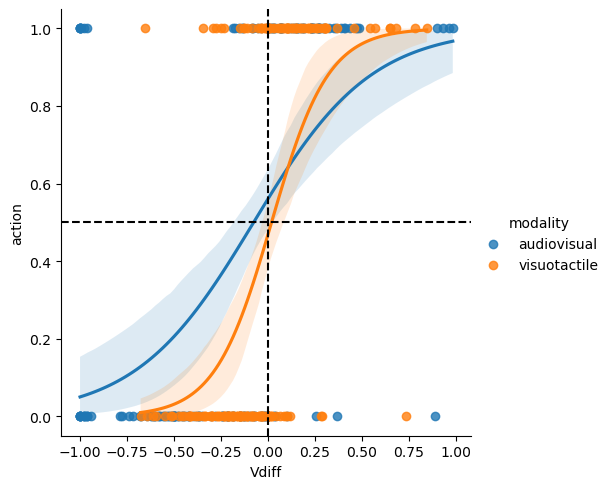

In [23]:
sns.lmplot(data=df, y='action', x='Vdiff', logistic=True, hue='modality')

plt.axhline(0.5, c='k', ls='--')
plt.axvline(0.0, c='k', ls='--')

In [7]:
# For all

In [2]:
# Importing the files with reaction time and with the fitted parameters

# Fitted parameter files
if platform.system() == "Windows":
    wanted_dir = "/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals"
else:
    wanted_dir = "/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals"

V0_files = [file for file in glob.glob(wanted_dir + '/**/V0*', recursive=True)]
V1_files = [file for file in glob.glob(wanted_dir + '/**/V1*', recursive=True)]
spe_files = [file for file in glob.glob(wanted_dir + '/**/spe.npy', recursive=True)]

# RT files
if platform.system() == "Windows":
    wanted_dir = "/data/sourcedata/behavior/modified_files"
else:
    wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

subjects = []
for i in range(len(spe_files)):
    subjects.append(int(spe_files[i][-10:-8]))

data_folder = '/Volumes/SDrive/data/'
# files


In [3]:
runNumber = np.tile(np.repeat(np.arange(1, 7), 60), 58)
trialNumber = np.tile(np.arange(1, 61), 6 * 58)

trialNumber

array([ 1,  2,  3, ..., 58, 59, 60])

In [4]:
V0_files

['/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-01/V0_PearceExtra.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-02/V0_PearceExtra.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-03/V0_PearceExtra.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-04/V0_PearceExtra.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-05/V0_PearceExtra.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-06/V0_PearceExtra.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-07/V0_Basic.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-09/V0_PearceExtra.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-10/V0_PearceExtra.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-11/V0_Basic.npy',
 '/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-12

In [5]:
# Creating dataFrame with relevant indices and fitted values and RT. 
subjects = []
Vdiff_abs_data = []
V0data = []
V1data = []
Vdiff_data = []
Vsum_data = []
spe_data = []

for i in range(len(spe_files)):
    spe = np.load(spe_files[i])
    spe_data.append(spe)
    V0 = np.load(V0_files[i])
    V1 = np.load(V1_files[i])
    print(np.shape(V0))
    V0data.append(V0)
    V1data.append(V1)
    # V1_data.append(V0)
    Vdiff = (V1 - V0)
    # print(np.shape(Vdiff))
    # Vdiff = (np.abs(V0-V1))
    Vdiff_abs = np.abs(Vdiff)    
    Vdiff_data.append(Vdiff)
    Vdiff_abs_data.append(Vdiff_abs)
    Vsum = (V0+V1)
    Vsum_data.append(Vsum)
    subjects.append(int(spe_files[i][-10:-8]))
    print(subjects[i])

# print(V0data)

# Flatten the data lists
V0data = np.array(V0data).flatten()
V1data = np.array(V1data).flatten()
Vdiff_data = np.array(Vdiff_data).flatten()
Vdiff_abs_data = np.array(Vdiff_abs_data).flatten()
Vsum_data = np.array(Vsum_data).flatten()
spe_data = np.array(spe_data).flatten()

# Create the index values for runNumber, trialNumber, and subject
subject = np.repeat(subjects, 6 * 60)
runNumber = np.tile(np.repeat(np.arange(1, 7), 60), 58)
trialNumber = np.tile(np.arange(1, 61), 6 * 58)

# Create the DataFrame
df = pd.DataFrame({
    'V0': V0data,
    'V1': V1data,
    'Vdiff_abs': Vdiff_abs_data,
    'Vdiff': Vdiff_data,    
    'Vsum': Vsum_data,
    'spe': spe_data,
    'runNumber': runNumber,
    'trialNumber': trialNumber,
    'subject': subject
})

# # Set the desired columns as the DataFrame's index
df.set_index(['runNumber', 'trialNumber', 'subject'], inplace=True)

RTdataset = []
for subject in subjects:
    file_path = op.join(data_folder, 'sourcedata', 'behavior', 'modified_files', f'modified_participant{subject:02d}_savedValues.csv')
    
    subject_rows = df.index.get_level_values('subject') == subject

    for key in ['responseTime', 'visual', 'audio', 'tactile', 'action']:
        # Read the CSV file and extract the 'responseTime' column
        data = pd.read_csv(file_path)[key]

        # Create the index values for the subject's rows in the DataFrame
        
        # Assign the 'responseTime' values to the corresponding subject in the DataFrame
        df.loc[subject_rows, key] = data.values



(6, 60)
1
(6, 60)
2
(6, 60)
3
(6, 60)
4
(6, 60)
5
(6, 60)
6
(6, 60)
7
(6, 60)
9
(6, 60)
10
(6, 60)
11
(6, 60)
12
(6, 60)
14
(6, 60)
15
(6, 60)
17
(6, 60)
18
(6, 60)
19
(6, 60)
20
(6, 60)
21
(6, 60)
22
(6, 60)
23
(6, 60)
24
(6, 60)
25
(6, 60)
26
(6, 60)
27
(6, 60)
28
(6, 60)
29
(6, 60)
30
(6, 60)
33
(6, 60)
34
(6, 60)
35
(6, 60)
36
(6, 60)
37
(6, 60)
38
(6, 60)
39
(6, 60)
40
(6, 60)
41
(6, 60)
42
(6, 60)
43
(6, 60)
45
(6, 60)
46
(6, 60)
47
(6, 60)
48
(6, 60)
49
(6, 60)
50
(6, 60)
51
(6, 60)
52
(6, 60)
53
(6, 60)
54
(6, 60)
55
(6, 60)
56
(6, 60)
57
(6, 60)
58
(6, 60)
59
(6, 60)
60
(6, 60)
61
(6, 60)
62
(6, 60)
63
(6, 60)
64


In [6]:
df.loc[df.audio.isnull(), 'modality']  = 'visuotactile'
df.loc[~df.audio.isnull(), 'modality']  = 'audiovisual'

In [7]:
import seaborn

In [8]:
df

V0        V1  Vdiff_abs     Vdiff  \
runNumber trialNumber subject                                            
1         1           1        0.500000  0.500000   0.000000  0.000000   
          2           1        0.500000  0.500000   0.000000  0.000000   
          3           1        0.500000  0.500000   0.000000  0.000000   
          4           1        0.500000  0.500000   0.000000  0.000000   
          5           1        0.500000  0.500000   0.000000  0.000000   
...                                 ...       ...        ...       ...   
6         56          64       0.054189  0.377760   0.323571  0.323571   
          57          64       0.630165  0.000000   0.630165 -0.630165   
          58          64       0.054189  0.506660   0.452472  0.452472   
          59          64       0.140491  0.418128   0.277637  0.277637   
          60          64       0.054189  0.399094   0.344905  0.344905   

                                   Vsum       spe  responseTime  visual  \
runNumber trialNumber subject                                             
1         1           1        1.000000  2.197225      2.226177     0.0   
          2           1        1.000000  2.302585      1.879317     1.0   
          3           1        1.000000  2.397895      2.399425     2.0   
          4           1        1.000000  2.484907      2.111797     0.0   
          5           1        1.000000  2.564949      1.813504     2.0   
...                                 ...       ...           ...     ...   
6         56          64       0.431949  3.060271      1.466607     0.0   
          57          64       0.630165  1.871802      1.213081     1.0   
          58          64       0.560849  2.397895      1.370891     2.0   
          59          64       0.558618  2.258782      1.331330     1.0   
          60          64       0.453283  2.273598      1.032242     2.0   

                               audio  tactile  action      modality  
runNumber trialNumber subject                                        
1         1           1          NaN      2.0     0.0  visuotactile  
          2           1          NaN      1.0     1.0  visuotactile  
          3           1          NaN      2.0     0.0  visuotactile  
          4           1          NaN      0.0     1.0  visuotactile  
          5           1          NaN      1.0     0.0  visuotactile  
...                              ...      ...     ...           ...  
6         56          64         1.0      NaN     1.0   audiovisual  
          57          64         0.0      NaN     0.0   audiovisual  
          58          64         2.0      NaN     1.0   audiovisual  
          59          64         1.0      NaN     1.0   audiovisual  
          60          64         2.0      NaN     1.0   audiovisual  

[20880 rows x 12 columns]

In [9]:
filtered_df = df[df['V1'] > 1]
selected_runs_subjects = filtered_df.index.get_level_values('runNumber'), filtered_df.index.get_level_values('subject')

selected_runs_subjects


(Int64Index([], dtype='int64', name='runNumber'),
 Int64Index([], dtype='int64', name='subject'))

In [10]:
df['V0'].min()

0.0

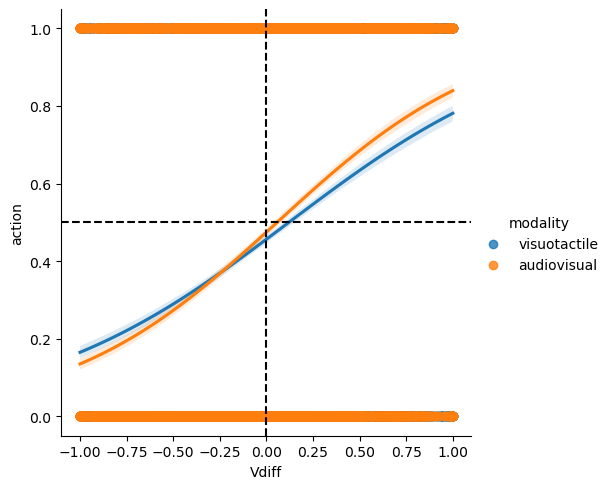

In [11]:
sns.lmplot(data=df, y='action', x='Vdiff', logistic=True, hue='modality')

plt.axhline(0.5, c='k', ls='--')
plt.axvline(0.0, c='k', ls='--')

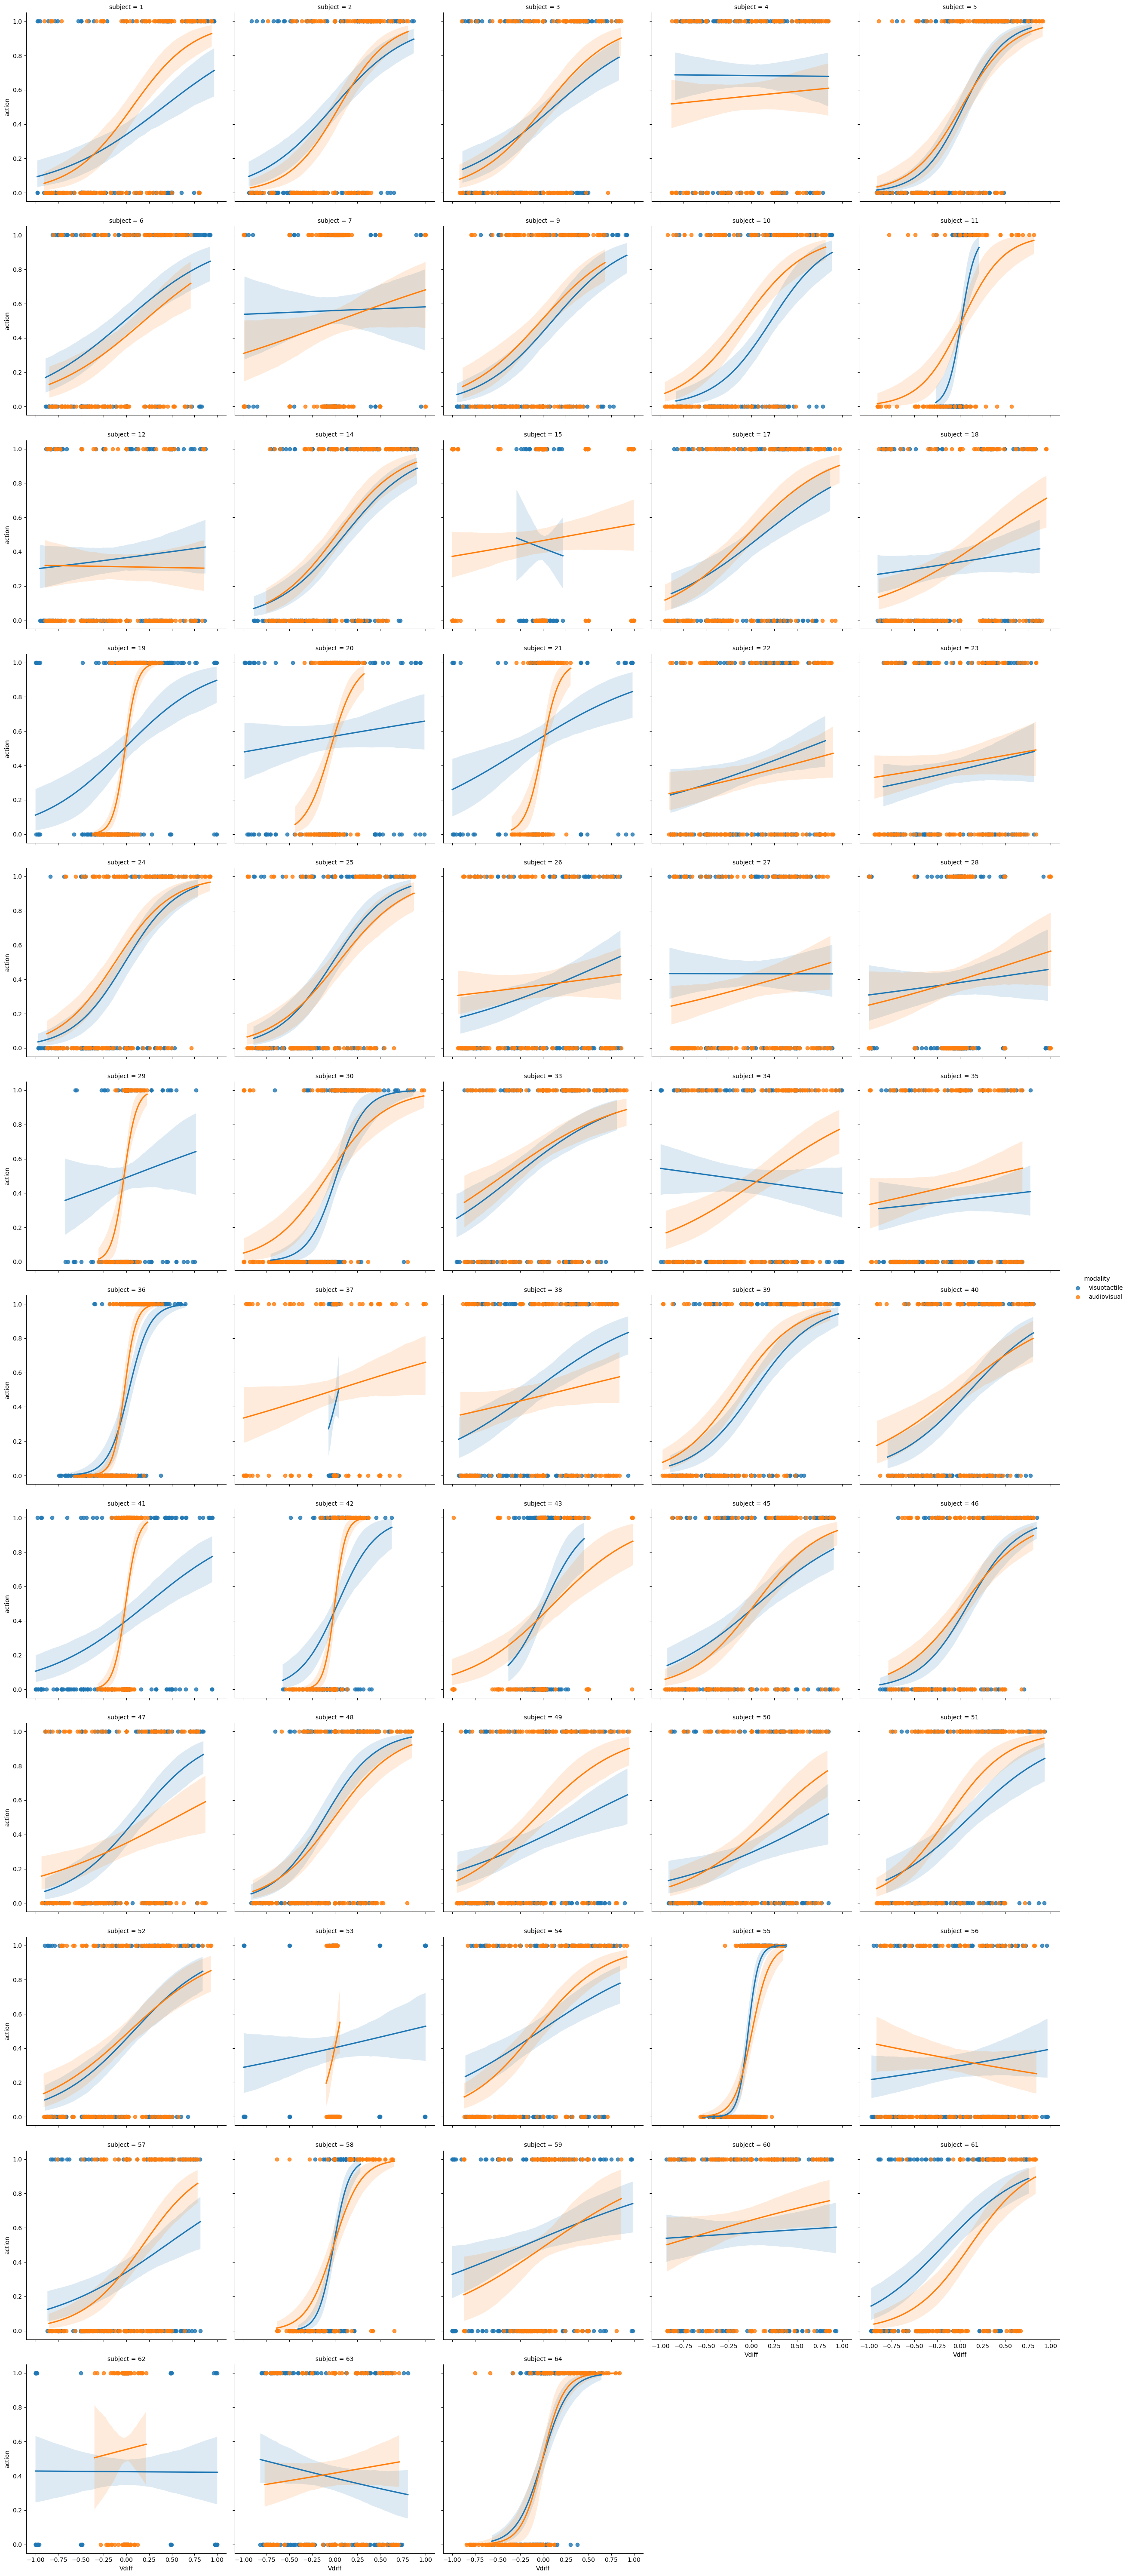

In [12]:
sns.lmplot(data=df.reset_index(), y='action', x='Vdiff', logistic=True, hue='modality', col = 'subject',  col_wrap = 5)

In [82]:
max_v0 = df['V0'].max()
max_v0

1.0

In [19]:
vdiff_subject_60 = df.loc[(df.index.get_level_values('subject') == 60), 'Vdiff'].values

min(vdiff_subject_60)

-0.5907603808965303

In [73]:
vdiff_subject_60_audiovisual = df.loc[(df.index.get_level_values('subject') == 60) & (df['modality'] == 'audiovisual'), 'Vdiff'].values

vdiff_subject_60_audiovisual


array([ 0.        ,  0.02839765, -0.02839765, -0.03854   ,  0.00161285,
       -0.06474876, -0.03915072, -0.0267848 , -0.09314641, -0.00914022,
        0.06916307,  0.03799865,  0.02781429, -0.07537779,  0.03830626,
        0.05520826,  0.06512161,  0.09477829, -0.06727479,  0.04889426,
       -0.02737257, -0.15813776, -0.12207395,  0.06482216,  0.09523847,
        0.14011952, -0.09287244,  0.10790649,  0.04266897,  0.09195585,
       -0.18697888,  0.03716467,  0.11843784,  0.00984256, -0.1856247 ,
       -0.19687327, -0.127367  , -0.20762996, -0.09455537,  0.15638938,
       -0.12013315, -0.22682229,  0.11023926,  0.06050467, -0.22617295,
       -0.14444915,  0.1967139 ,  0.15425835,  0.08633028, -0.26575272,
       -0.21834178, -0.28349908,  0.16503978,  0.10134301,  0.21055987,
       -0.20849184, -0.26284399, -0.17469113, -0.25856305,  0.08437369,
        0.        , -0.0587198 , -0.0587198 , -0.1174396 ,  0.10848005,
        0.15239648, -0.04286422,  0.10848005,  0.19906272,  0.02

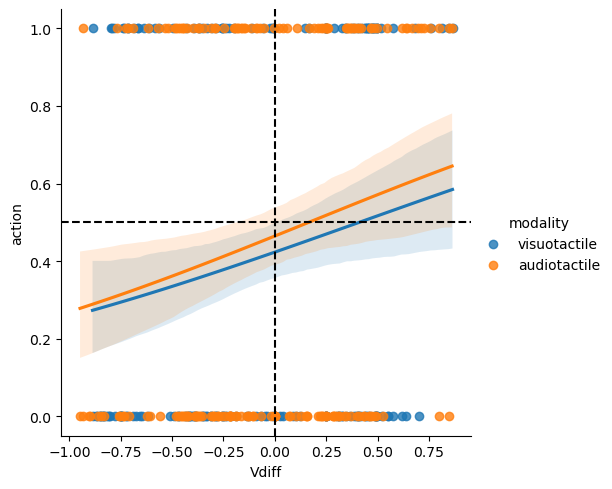

In [28]:
sns.lmplot(data=df.xs(3, 0, 'subject'), y='action', x='Vdiff', hue='modality', logistic=True)

plt.axhline(0.5, c='k', ls='--')
plt.axvline(0.0, c='k', ls='--')

In [27]:
df.xs(2, 0, 'subject')

Vdiff_abs     Vdiff      Vsum       spe  responseTime  \
runNumber trialNumber                                                          
1         1             0.000000  0.000000  1.000000  2.197225      2.282078   
          2             0.262796 -0.262796  1.262796  2.302585      2.078833   
          3             0.250655 -0.250655  1.250655  2.397895      1.784822   
          4             0.250034  0.250034  0.749966  1.791759      2.155057   
          5             0.008019  0.008019  1.509329  1.871802      2.588736   
...                          ...       ...       ...       ...           ...   
          56            0.463300  0.463300  1.463300  3.060271           NaN   
          57            0.357235  0.357235  1.357235  3.075775      1.179574   
          58            0.131317  0.131317  1.131317  1.992430      1.426099   
          59            0.382339 -0.382339  1.047167  1.902108      1.420355   
          60            0.289616 -0.289616  1.289616  1.916923      1.239687   

                       visual  audio  tactile  action      modality  response  \
runNumber trialNumber                                                           
1         1               0.0    NaN      0.0     0.0  visuotactile       0.0   
          2               1.0    NaN      2.0     0.0  visuotactile       0.0   
          3               2.0    NaN      1.0     0.0  visuotactile       0.0   
          4               1.0    NaN      2.0     1.0  visuotactile       1.0   
          5               0.0    NaN      0.0     0.0  visuotactile       0.0   
...                       ...    ...      ...     ...           ...       ...   
          56              1.0    2.0      NaN     NaN  audiotactile       NaN   
          57              2.0    1.0      NaN     1.0  audiotactile       1.0   
          58              0.0    2.0      NaN     0.0  audiotactile       0.0   
          59              2.0    0.0      NaN     0.0  audiotactile       0.0   
          60              0.0    2.0      NaN     0.0  audiotactile       0.0   

                        rt  
runNumber trialNumber       
1         1            0.0  
          2            0.0  
          3            0.0  
          4            1.0  
          5            0.0  
...                    ...  
          56           NaN  
          57           1.0  
          58           0.0  
          59           0.0  
          60           0.0  

[360 rows x 12 columns]

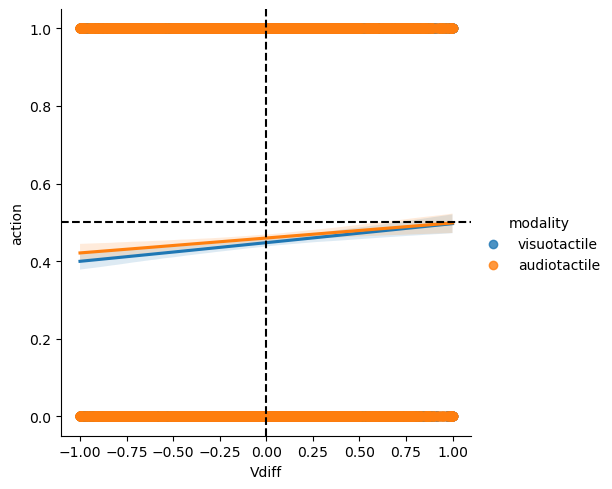

In [21]:
sns.lmplot(data=df, y='action', x='Vdiff', logistic=True, hue='modality')

plt.axhline(0.5, c='k', ls='--')
plt.axvline(0.0, c='k', ls='--')

In [18]:
df['response'] = df['action']
df['rt'] = df['action']

In [19]:
df_audio = df[~df.audio.isnull()]
df_tactile = df[~df.tactile.isnull()]

In [ ]:
import hddm

In [ ]:
v_reg = {'model': 'v ~ 0 + Vdiff + Vdiff:spe'}
reg_desc = [v_reg]

m1_audio = hddm.HDDMRegressor(df_audio, reg_desc, include=['v', 'a', 't', 'z'])

In [ ]:
v_reg = {'model': 'v ~ 0 + Vdiff'}
t0_reg = {'model': 't ~ 1 + spe'}
reg_desc = [v_reg, t0_reg]

m2_audio = hddm.HDDMRegressor(df_audio, reg_desc, include=['v', 'a', 't', 'z'])


In [ ]:
v_reg = {'model': 'v ~ 0 + Vdiff'}
a_reg = {'model': 'a ~ 1 + spe'}
reg_descr = [v_reg, a_reg]

m3_audio = hddm.HDDMRegressor(df_audio, reg_desc, include=['v', 'a', 't', 'z'])
